In [5]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
import warnings


def son_similares(cadena1, cadena2):
    return SequenceMatcher(None, cadena1, cadena2).ratio()

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

new = pd.read_csv(path_data / '2024-12-16_Egresos.csv',encoding= 'latin1', sep = '|')
egresos = pd.read_csv(path_data / "egresos.csv",encoding = "latin1",sep="|")

comunas = pd.read_excel(path_data/"comunas.xlsx")
comunas = comunas.drop_duplicates()
comunas = comunas.rename(columns = {'C_COM': 'COMUNA','NOM_REG':'NOMBRE_REGION'})

egresos = (
    pd.concat([egresos,new])
    .rename(columns={'RUT':'RUN'})
    .assign(FECHA_NAC = lambda x: pd.to_datetime({'year': x['A_NAC'], 'month': x['M_NAC'], 'day': x['D_NAC']}, format='%Y-%m-%d'),
            fechaIng = lambda x: pd.to_datetime({'year': x['ANO_ING'], 'month': x['MES_ING'], 'day': x['DIA_ING']}, format='%Y-%m-%d'),
            fechaEgr = lambda x: pd.to_datetime({'year': x['ANO_EGR'], 'month': x['MES_EGR'], 'day': x['DIA_EGR']}, format='%Y-%m-%d'),
            age=lambda x: ((x['fechaIng'] - x['FECHA_NAC']).dt.days / 28))
    .merge(comunas,how='left',on ='COMUNA')
    .assign(NOMBRE_REGION = lambda x: (x['NOMBRE_REGION'].str.replace('Región', '').str.strip()).fillna('Ignorada'))
    .query("age <= 48")
)

C:\Users\ntrig\AppData\Local\Temp\ipykernel_15328\347415163.py:34: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  new = pd.read_csv(path_data / '2024-12-16_Egresos.csv',encoding= 'latin1', sep = '|')
C:\Users\ntrig\AppData\Local\Temp\ipykernel_15328\347415163.py:35: DtypeWarning: Columns (11,76,77,78,79,80,81,82,83,84) have mixed types. Specify dtype option on import or set low_memory=False.
  egresos = pd.read_csv(path_data / "egresos.csv",encoding = "latin1",sep="|")


In [ ]:
df_filtrado = egresos[['RUN', 'FECHA_NAC', 'fechaIng', 'DIAG1', 'age', 'SEXO','NOMBRE_REGION','AREA_FUNC_I', 'ANO_ING','ESTAB',
                           'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS',
                            'DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS', 'DIA_3_TRAS',
                            'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS', 'DIA_4_TRAS', 'MES_4_TRAS',
                            'ANO_4_TRAS', 'AREAF_4_TRAS', 'DIA_5_TRAS', 'MES_5_TRAS', 'ANO_5_TRAS',
                            'AREAF_5_TRAS', 'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS',
                            'AREAF_6_TRAS', 'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS',
                            'AREAF_7_TRAS', 'DIA_8_TRAS', 'MES_8_TRAS', 'ANO_8_TRAS',
                            'AREAF_8_TRAS', 'DIA_9_TRAS', 'MES_9_TRAS', 'ANO_9_TRAS',
                            'AREAF_9_TRAS','DIAS_ESTAD','fechaEgr']]

e24 = df_filtrado[df_filtrado.ANO_ING ==2024]
dataprev = df_filtrado[df_filtrado.ANO_ING !=2024]

e24.to_csv(path_data/"egresos2024.csv")
dataprev.to_csv(path_data/"dataprev.csv")
df_filtrado.to_csv(path_data/"full_data.csv")


trib_publi = pd.read_excel(path_data/"EstadoCargaIEEH_SS_181224.xlsx", skiprows=2)
trib_priv = pd.read_excel(path_data/"EstadoCargaIEEH__SEREMI_18122024.xlsx", skiprows=2)#, skiprows=2
trib = pd.concat([trib_publi,trib_priv]).rename(columns={'Codigo Establecimiento':'CodigoEstablecimiento'}).assign(trib_suf = lambda x: 0.8 * x.Ag >= x.Sept)
acusados = trib[trib['Sept'].isna()].CodigoEstablecimiento
acusados = acusados.dropna().astype(int).unique()
acusados_2 = trib[(trib.trib_suf) & (trib.CodigoEstablecimiento.notna())].CodigoEstablecimiento.unique()

diagnosticos_upc = [406, 412, 415, 405, 411, 414]
cols_diagnostico = ['AREA_FUNC_I','AREAF_1_TRAS', 'AREAF_2_TRAS', 'AREAF_3_TRAS', 'AREAF_4_TRAS', 'AREAF_5_TRAS', 'AREAF_6_TRAS', 'AREAF_7_TRAS', 'AREAF_8_TRAS', 'AREAF_9_TRAS']
tras_date = {'AREA_FUNC_I': 'fechaIng','AREAF_1_TRAS':'fecha_tras_1', 'AREAF_2_TRAS':'fecha_tras_2', 'AREAF_3_TRAS':'fecha_tras_3', 'AREAF_4_TRAS':'fecha_tras_4', 'AREAF_5_TRAS':'fecha_tras_5'
             , 'AREAF_6_TRAS':'fecha_tras_6', 'AREAF_7_TRAS':'fecha_tras_7', 'AREAF_8_TRAS':'fecha_tras_8', 'AREAF_9_TRAS':'fecha_tras_9'}

def obtener_fecha_primer_upc(row):
    for col in cols_diagnostico:
        if row[col] == 1:
            fecha_col = tras_date[col]
            return row[fecha_col]
    return None

In [ ]:
elementos = ['J121', 'J205', 'J210','J219', 'B974' ]
df_filtrado = egresos[egresos[['DIAG1'#,'DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11'
                               ]].isin(elementos).any(axis=1)]

df_filtrado = df_filtrado.assign(VRS1 = 1)

In [37]:
####################################################################################################################################################################################

data = (
    pd.read_csv(path_data/"full_data.csv")[['RUN', 'FECHA_NAC','fechaEgr', 'fechaIng','DIAG1','age']]
    .assign(FECHA_NAC=lambda data: pd.to_datetime(data["FECHA_NAC"], format="%Y-%m-%d"),
            fechaIng=lambda data: pd.to_datetime(data["fechaIng"], format="%Y-%m-%d"),
            fechaEgr=lambda data: pd.to_datetime(data["fechaEgr"], format="%Y-%m-%d"),
            epiweek=lambda x: x['fechaIng'].dt.isocalendar().week,
            year=lambda x: x['fechaIng'].dt.isocalendar().year)
    .drop_duplicates(subset=['RUN','fechaIng'], keep='first')
)


catchup24 =( 
    data.query("'2023-10-01' <= FECHA_NAC <= '2024-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2024)
)
inseason24 = (
    data.query("'2024-04-01' <= FECHA_NAC <= '2024-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2024)
)
catchup23 =( 
    data.query("'2022-10-01' <= FECHA_NAC <= '2023-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2023)
)
inseason23 = (
    data.query("'2023-04-01' <= FECHA_NAC <= '2023-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2023)
)
catchup22 =( 
    data.query("'2021-10-01' <= FECHA_NAC <= '2022-03-31'")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2022)
)
inseason22 = (
    data.query("'2022-04-01' <= FECHA_NAC <= '2022-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2022)
)
#########################################
catchup21=( 
    data.query("'2020-10-01' <= FECHA_NAC <= '2021-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2021)
)
inseason21 = (
    data.query("'2021-04-01' <= FECHA_NAC <= '2021-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2021)
)
catchup20=( 
    data.query("'2019-10-01' <= FECHA_NAC <= '2020-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2020)
)
inseason20 = (
    data.query("'2020-04-01' <= FECHA_NAC <= '2020-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2020)
)
catchup18=( 
    data.query("'2017-10-01' <= FECHA_NAC <= '2018-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2018)
)
inseason18 = (
    data.query("'2018-04-01' <= FECHA_NAC <= '2018-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2018)
)
#########################################

catchup19=( 
    data.query("'2018-10-01' <= FECHA_NAC <= '2019-03-31' ")
    .assign(season = lambda x: 'pre_season').assign(elegibilidad = lambda x: 2019)
)
inseason19 = (
    data.query("'2019-04-01' <= FECHA_NAC <= '2019-09-30'")
    .assign(season = lambda x: 'in_season').assign(elegibilidad = lambda x: 2019)
)

#merge seasons
seasons = pd.concat([catchup24,inseason24,catchup23,inseason23,catchup22,inseason22,
                     catchup21,inseason21,catchup20,inseason20,
                     catchup19,inseason19,catchup18,inseason18,
                     ])[['RUN','fechaIng','season','elegibilidad']]

df = data.merge(seasons, how='left', on=['RUN','fechaIng'])
df['elegibilidad'] = df['elegibilidad'].fillna(0)
df['season'] = df['season'].fillna('nonelegible')
df_safe=df.copy()

In [114]:
df=df_safe.copy()

In [115]:
#merge egresos
egresosprev = (pd.read_csv(path_data/'dataprev.csv')
               .assign(fechaIng = lambda x: pd.to_datetime(x['fechaIng'], format='%Y-%m-%d'),
                       fechaEgr = lambda x: pd.to_datetime(x['fechaEgr'], format='%Y-%m-%d')))
egresos24 = (pd.read_csv(path_data/"egresos2024.csv")
             .assign(fechaIng = lambda x: pd.to_datetime(x['fechaIng'], format='%Y-%m-%d'),
                       fechaEgr = lambda x: pd.to_datetime(x['fechaEgr'], format='%Y-%m-%d')))

for i in range(1, 10):
    year_col = f'ANO_{i}_TRAS'
    month_col = f'MES_{i}_TRAS'
    day_col = f'DIA_{i}_TRAS'
    date_col = f'fecha_tras_{i}'

    # Combinar las columnas de año, mes y día en una columna de fecha
    egresosprev[date_col] = pd.to_datetime({'year': egresosprev[year_col], 'month': egresosprev[month_col], 'day': egresosprev[day_col]}, format='%Y-%m-%d')
    egresos24[date_col] = pd.to_datetime({'year': egresos24[year_col], 'month': egresos24[month_col], 'day': egresos24[day_col]}, format='%Y-%m-%d')

for col in cols_diagnostico:
    egresosprev[col] = egresosprev[col].apply(lambda x: 1 if x in diagnosticos_upc else 0)
    egresos24[col] = egresos24[col].apply(lambda x: 1 if x in diagnosticos_upc else 0)

egresosprev['cama'] = np.where(egresosprev[cols_diagnostico].eq(1).any(axis=1), 'UPC', "")
egresosprev['critico'] = np.where(egresosprev[cols_diagnostico].eq(1).any(axis=1), 1, 0)
egresosprev['ingreso_UPC'] = egresosprev.apply(obtener_fecha_primer_upc, axis=1)
egresos24['critico'] = np.where(egresos24[cols_diagnostico].eq(1).any(axis=1), 1, 0)
egresos24['cama'] = np.where(egresos24[cols_diagnostico].eq(1).any(axis=1), 'UPC', "")
egresos24['ingreso_UPC'] = egresos24.apply(obtener_fecha_primer_upc, axis=1)


egresos = (pd.concat([egresosprev, egresos24], ignore_index=True)
           .sort_values('fechaIng').drop_duplicates(subset=['RUN','fechaIng'], keep='first')
)


egresos = egresos[['RUN','NOMBRE_REGION','SEXO','cama','ingreso_UPC','critico','fechaIng','ESTAB','fecha_tras_1'
                   ,'fecha_tras_2','fecha_tras_3','fecha_tras_4','fecha_tras_5','fecha_tras_6','fecha_tras_7','fecha_tras_8'
                   ,'fecha_tras_9','DIAS_ESTAD','fechaEgr','AREAF_1_TRAS','AREAF_2_TRAS','AREAF_3_TRAS','AREAF_4_TRAS',
                   'AREAF_5_TRAS','AREAF_6_TRAS','AREAF_7_TRAS','AREAF_8_TRAS','AREAF_9_TRAS','AREA_FUNC_I']]

df = df.merge(egresos, how = 'left', on = ['RUN','fechaIng','fechaEgr'
                                           ])   ##########agregé egreso#####################

regiones = {
'Metropolitana de Santiago': 'METROPOLITANA',
'De Los Lagos': 'LOS LAGOS',
'De Valparaíso': 'VALPARAISO',
'Extranjero': 'EXTRANJERO',
'De Tarapacá': 'TARAPACA',
'Del Maule': 'MAULE',
'De Ñuble': 'NUBLE',
'Del Bíobío': 'BIOBIO',
"Del Libertador B. O'Higgins": "O'HIGGINS",
'De La Araucanía': 'ARAUCANIA',
'De Aisén del Gral. C. Ibáñez del Campo': 'AISEN',
'De Coquimbo': 'COQUIMBO',
'De Arica y Parinacota': 'ARICA Y PARINACOTA',
'De Antofagasta': 'ANTOFAGASTA',
'De Magallanes y de La Antártica Chilena': 'MAGALLANES Y ANTARTICA',
'De Los Ríos': 'LOS RIOS',
'Ignorada' : None,
'De Atacama': 'ATACAMA'
}


sex = {'2.0':'Female','1.0':'Male','99.0':'desconocido','3.0':'desconocido'}
df['SEXO'] = np.where(df.SEXO.isna(), 'desconocido', df.SEXO.astype(str))

#df['SEXO'] = df['SEXO'].astype(int).astype(str)
#df['SEXO'] = df['SEXO'].astype(str)

cache={}
L=[]

def mapear_region(region, regiones_dict):
    if region in cache:  # Revisar si ya está en caché
        L.append(f"{region}---->{cache[region]}")
        return cache[region]

    mejor_similitud = 0
    mejor_region = None
    for key, value in regiones_dict.items():
        similitud = SequenceMatcher(None, region, key).ratio()
        if similitud > mejor_similitud:
            mejor_similitud = similitud
            mejor_region = value

    resultado = mejor_region if mejor_similitud > 0 else None
    cache[region] = resultado
    L.append(f"{region}---->{resultado}")
    return resultado

In [117]:
df.SEXO.unique()

array(['2.0', '1.0', 'desconocido', '99.0', '3.0'], dtype=object)

In [103]:
df_copy_2 = df.copy()

In [111]:
df = df_copy_2.copy()

In [118]:
df['NOMBRE_REGION'] = df['NOMBRE_REGION'].dropna().apply(lambda x: mapear_region(x, regiones))
print(np.unique(L))

region_a_macrozona = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",  # Atacama se cubre con Tarapacá
    "COQUIMBO": "Macrozona Centro",  # Coquimbo se cubre con Valparaíso
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Macrozona METROPOLITANA",
    "O'HIGGINS": "Macrozona Centro Sur",
    "MAULE": "Macrozona Centro Sur",  # Maule se cubre con Biobío
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Sur",  # Araucanía se cubre con Los Ríos y Los Lagos
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"#,

} 

df['Macrozona'] = df['NOMBRE_REGION'].map(region_a_macrozona)

region_a_macrozona2 = {
    "ARICA Y PARINACOTA": "Norte",
    "TARAPACA": "Norte",
    "ANTOFAGASTA": "Norte",
    "ATACAMA": "Norte",  # Atacama se cubre con Tarapacá
    "COQUIMBO": "Centro",  # Coquimbo se cubre con Valparaíso
    "VALPARAISO": "Centro",
    "METROPOLITANA": "Centro",
    "O'HIGGINS": "Centro",
    "MAULE": "Centro",  # Maule se cubre con Biobío
    "NUBLE": "Centro",
    "BIOBIO": "Centro",
    "ARAUCANIA": "Sur",  # Araucanía se cubre con Los Ríos y Los Lagos
    "LOS RIOS": "Sur",
    "LOS LAGOS": "Sur",
    "AISEN": "Sur",
    "MAGALLANES Y ANTARTICA": "Sur"#,
} 

df['Macrozona2'] = df['NOMBRE_REGION'].map(region_a_macrozona2)

df['SEXO'] = df['SEXO'].map(sex)
df['age'] = df['age'].astype(int)

['De Antofagasta---->ANTOFAGASTA'
 'De Arica Parinacota---->ARICA Y PARINACOTA' 'De Atacama---->ATACAMA'
 'De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'De Coquimbo---->COQUIMBO' 'De La Araucanía---->ARAUCANIA'
 'De Los Lagos---->LOS LAGOS' 'De Los Ríos---->LOS RIOS'
 'De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'De Tarapacá---->TARAPACA' 'De Valparaíso---->VALPARAISO'
 'De los Ríos---->LOS RIOS' 'De Ñuble---->NUBLE' 'Del Bíobío---->BIOBIO'
 "Del Libertador Gral. B. O'Higgins---->O'HIGGINS" 'Del Maule---->MAULE'
 'Ignorada---->None' 'Metropolitana de Santiago---->METROPOLITANA']


In [122]:
df = (df
      .rename(columns ={'NOMBRE_REGION':'region','SEXO':'sex'})
      .dropna(subset=['region','sex','elegibilidad'])
      .assign(epiweekupc = lambda x: x.ingreso_UPC.dt.isocalendar().week.fillna(-1).astype(int))
      .drop_duplicates()
)

df_sintribu=df.copy()
df = df[~df['ESTAB'].isin(acusados)]
df = df[~df['ESTAB'].isin(acusados_2)]

df = df.query('(year < 2024) | (year==2024) ') #FILTRADO FECHAS PEDIDO PROFES  & epiweek<=40 & epiweekupc<=40
df_sintribu = df_sintribu.query('(year < 2024) | (year==2024) ') # & epiweek<=33 & epiweekupc<=33 & epiweek<=40 & epiweekupc<=40
df.to_csv(path_data/"data.csv")

df[df.year!=2018].groupby(['year','epiweek','elegibilidad','critico'],as_index=False)[['RUN']].count().rename(columns={'RUN':'Count'}).to_csv(path_data/'data_download.csv')

In [123]:
df

,RUN,FECHA_NAC,fechaEgr,fechaIng,DIAG1,age,epiweek,year,season,elegibilidad,...,AREAF_4_TRAS,AREAF_5_TRAS,AREAF_6_TRAS,AREAF_7_TRAS,AREAF_8_TRAS,AREAF_9_TRAS,AREA_FUNC_I,Macrozona,Macrozona2,epiweekupc
1,5d227f3aa6732dbb9f36bfafec9f2e1fff3ea5b81aa8c5...,2018-09-14,2019-07-03,2019-07-01,J22X,10,27,2019,in_season,2018.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Centro,Centro,-1
2,a45c240262a9ec36c6fb498cb4835fec4548d76d6c8d12...,2018-09-07,2019-08-28,2019-08-27,J121,12,35,2019,in_season,2018.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Centro Sur,Centro,-1
3,03196d46f41d82acd46222181b008683ac1c78d8637049...,2018-08-03,2019-05-27,2019-05-25,A099,10,21,2019,in_season,2018.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Centro Sur,Centro,-1
4,48bbeba41e725b2ffb387c38c4d18126c0268b5a3fe43a...,2019-03-22,2019-07-29,2019-07-21,J210,4,29,2019,pre_season,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Macrozona Centro Sur,Centro,29
5,ed78341a5cf6c4537eb118e7aa2fe9eb5d6bf03aedf2fe...,2019-03-23,2019-04-04,2019-04-01,P599,0,14,2019,pre_season,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Centro Sur,Centro,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550326,6a0aecff6b502e47bd9be0841a375f2271cc39e45219c7...,2024-09-16,2024-10-29,2024-09-23,P578,0,39,2024,in_season,2024.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Macrozona Centro Sur,Centro,39
550327,574117ad83d06f7f245ea1663e93aabc109bd02ec5e770...,2024-10-04,2024-10-10,2024-10-04,Q764,0,40,2024,nonelegible,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Macrozona Centro Sur,Centro,40
550328,96555d72520c82a9ef338fc2ce5bd0858a7743b17234b6...,2020-12-28,2024-08-13,2024-08-13,N47X,47,33,2024,pre_season,2021.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona METROPOLITANA,Centro,-1
550329,b838efb72ce37c88e540b2eb61bc31666e795623f4eff0...,2021-02-25,2024-07-23,2024-07-23,N47X,44,30,2024,pre_season,2021.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona METROPOLITANA,Centro,-1


### CURVES

In [ ]:
path_nirsecl = path_actual.parent.parent/'Nirse_cl' / 'Data'
df_historic = pd.read_csv(path_nirsecl/"data.csv").drop(columns=['Unnamed: 0'])
df_historic[['RUN', 'FECHA_NAC', 'fechaIng', 'epiweek', 'year','season', 'elegibilidad', 'cama', 'ingreso_UPC','critico', 'epiweekupc']]
df_nirse = df_historic.assign(is_elegible = lambda x: x.year == x.elegibilidad,
                              hospitalizado = lambda x: np.where(x['fechaIng'].notna(), 1, 0))#.query('epiweek<=40')

df_elig = df_nirse[df_nirse['is_elegible'] == True]
df_no_elig = df_nirse[df_nirse['is_elegible'] == False]

df_elig_agg = (df_elig.groupby(['year', 'epiweek'])['hospitalizado']
                      .sum()
                      .reset_index())

# Ahora, calcular el acumulado por año
df_elig_agg['hospitalizado_acumulado'] = df_elig_agg.groupby('year')['hospitalizado'].cumsum()

df_no_elig_agg = (df_no_elig.groupby(['year', 'epiweek'])['hospitalizado']
                          .sum()
                          .reset_index())

df_no_elig_agg['hospitalizado_acumulado'] = df_no_elig_agg.groupby('year')['hospitalizado'].cumsum()

years_line = [2019, 2022, 2023]
year_hist = 2024

df_elig_line = df_elig_agg[df_elig_agg['year'].isin(years_line)]
df_elig_hist = df_elig_agg[df_elig_agg['year'] == year_hist]

df_no_elig_line = df_no_elig_agg[df_no_elig_agg['year'].isin(years_line)]
df_no_elig_hist = df_no_elig_agg[df_no_elig_agg['year'] == year_hist]

C:\Users\ntrig\AppData\Local\Temp\ipykernel_15328\2887038993.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_historic = pd.read_csv(path_nirsecl/"data.csv").drop(columns=['Unnamed: 0'])


In [168]:
df_elig_line[df_elig_line.epiweek == df_elig_hist.epiweek.max()][['year','hospitalizado_acumulado']].set_index('year').reset_index().mean().to_frame().T

,year,hospitalizado_acumulado
0,2021.333333,44827.666667


In [169]:
elegibles_data_max_hosp = (
    pd.concat([df_elig_hist[df_elig_hist.epiweek == df_elig_hist.epiweek.max()][['year','hospitalizado_acumulado']].set_index('year').reset_index(), 
               df_elig_line[df_elig_line.epiweek == df_elig_hist.epiweek.max()][['year','hospitalizado_acumulado']].set_index('year').reset_index().mean().to_frame().T])
    .assign(elegibles = 1)
)
non_elegibles_data_max_hosp = (
    pd.concat([df_no_elig_hist[df_no_elig_hist.epiweek == df_no_elig_hist.epiweek.max()][['year','hospitalizado_acumulado']].set_index('year').reset_index(), df_no_elig_line[df_no_elig_line.epiweek == df_no_elig_hist.epiweek.max()][['year','hospitalizado_acumulado']].set_index('year').reset_index().mean().to_frame().T])
    .assign(elegibles = 0)
)

data_compare = pd.concat([elegibles_data_max_hosp,non_elegibles_data_max_hosp])

In [170]:
data_compare

,year,hospitalizado_acumulado,elegibles
0,2024.000000,32118.000000,1
0,2021.333333,44827.666667,1
0,2024.000000,32557.000000,0
0,2021.333333,43761.000000,0


In [171]:
# Pivotear los datos para que cada año tenga hospitalizados separados por elegibilidad
df_pivot = data_compare.pivot(index="year", columns="elegibles", values="hospitalizado_acumulado")

# Renombrar columnas para mayor claridad
df_pivot.columns = ["no_elegibles", "elegibles"]

# Calcular la diferencia
df_pivot["diferencia_hospitalizados"] = df_pivot["elegibles"] - df_pivot["no_elegibles"]

# Resetear índice si lo quieres como columna normal
df_pivot.reset_index(inplace=True)

In [172]:
df_pivot

,year,no_elegibles,elegibles,diferencia_hospitalizados
0,2021.333333,43761.0,44827.666667,1066.666667
1,2024.000000,32557.0,32118.000000,-439.000000


C:\Users\ntrig\AppData\Local\Temp\ipykernel_15328\844474208.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_historic = pd.read_csv(path_nirsecl/"data.csv").drop(columns=['Unnamed: 0'])


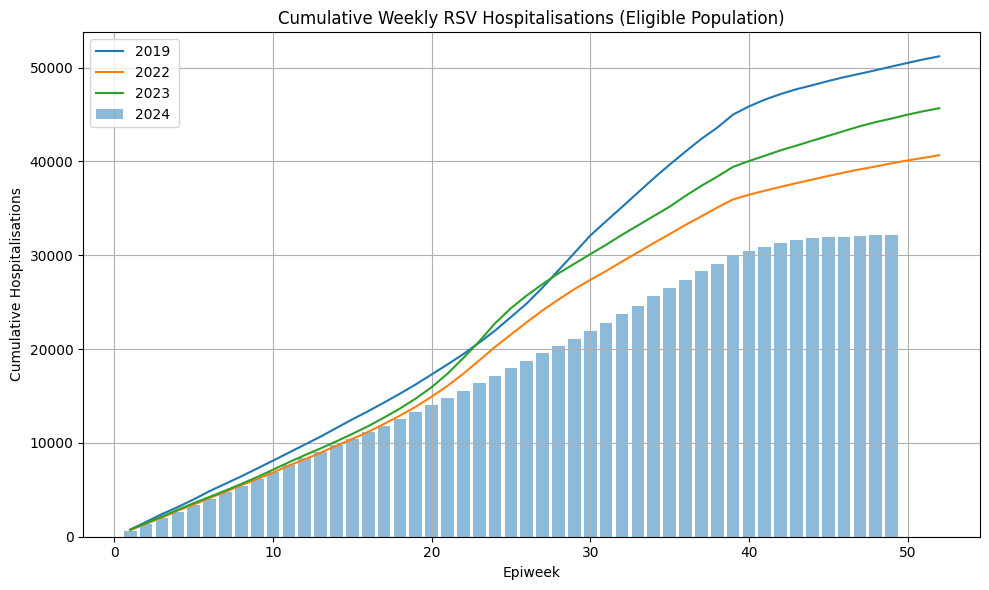

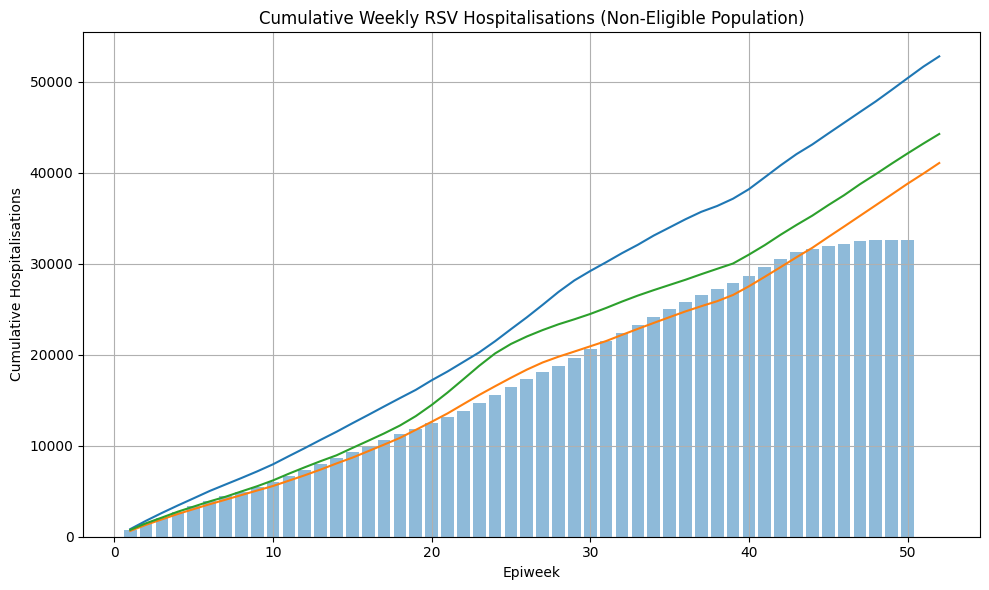

In [ ]:

fig, ax = plt.subplots(figsize=(10,6))

# Graficar las líneas
for y in years_line:
    data_y = df_elig_line[df_elig_line['year'] == y]
    ax.plot(data_y['epiweek'], data_y['hospitalizado_acumulado'], label=str(y))
    

data_2024 = df_elig_hist
ax.bar(data_2024['epiweek'], data_2024['hospitalizado_acumulado'], 
       alpha=0.5, label='2024 ')

ax.set_xlabel('Epiweek')
ax.set_ylabel('Cumulative Hospitalisations')
ax.set_title('Cumulative Weekly RSV Hospitalisations (Eligible Population)')
ax.legend()
ax.tick_params(axis='both', which='major')
ax.grid(True)
plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(10,6))

# Líneas para 2019, 2022, 2023
df_no_elig_line = df_no_elig_agg[df_no_elig_agg['year'].isin(years_line)]
df_no_elig_hist = df_no_elig_agg[df_no_elig_agg['year'] == year_hist]

for y in years_line:
    data_y = df_no_elig_line[df_no_elig_line['year'] == y]
    ax.plot(data_y['epiweek'], data_y['hospitalizado_acumulado'], label=str(y))
    
# Histograma para 2024
data_2024_no_elig = df_no_elig_hist
ax.bar(data_2024_no_elig['epiweek'], data_2024_no_elig['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek')
ax.set_ylabel('Cumulative Hospitalisations')
ax.set_title('Cumulative Weekly RSV Hospitalisations (Non-Eligible Population)')
#ax.legend()
ax.tick_params(axis='both', which='major')
ax.grid(True)
plt.tight_layout()
plt.show()

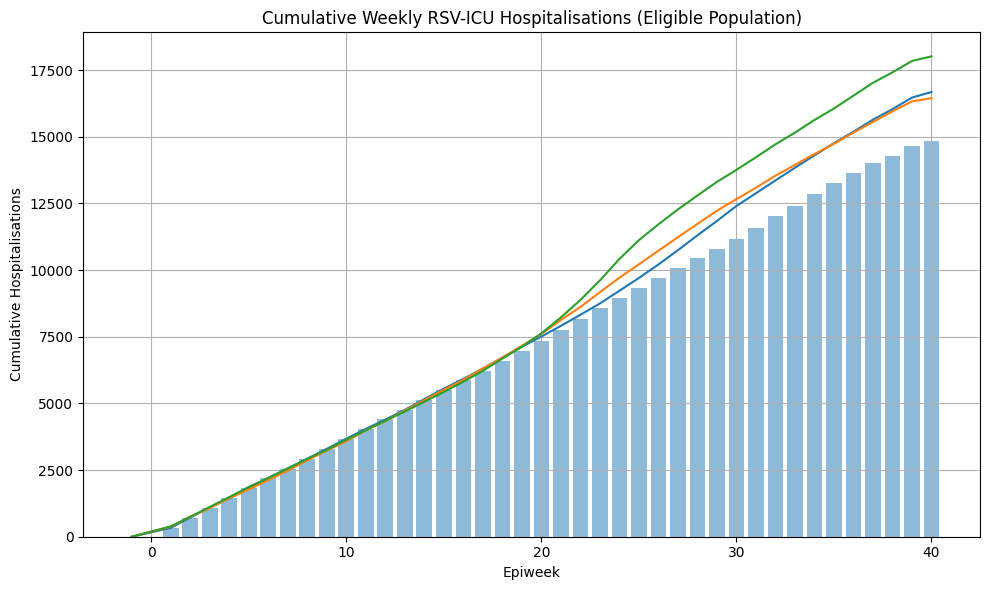

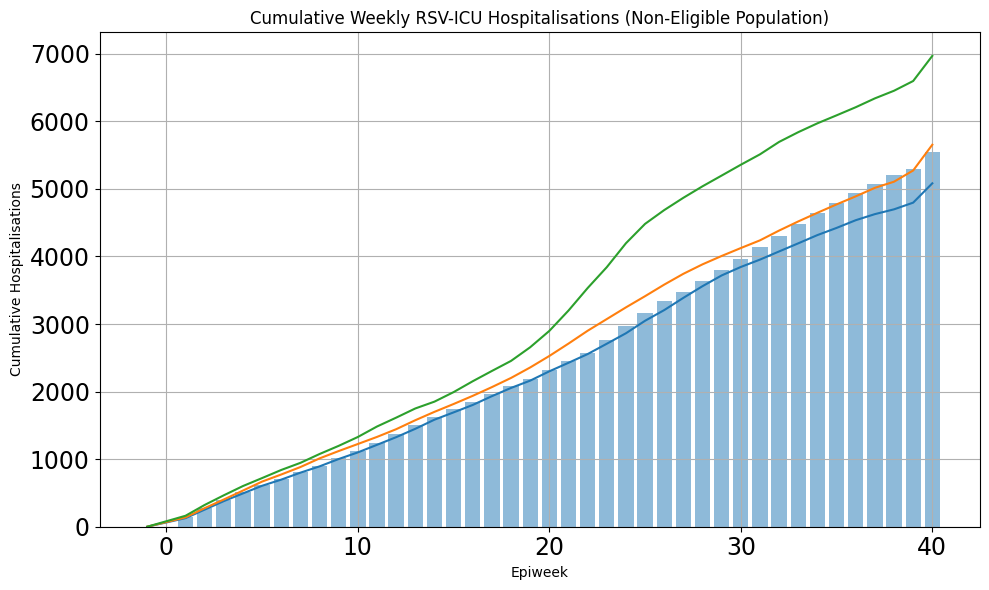

In [ ]:
def agregate_week(df, year, week):
    new_row = {'year': year, 'epiweekupc': week, 'hospitalizado': 0, 'hospitalizado_acumulado': df['hospitalizado_acumulado'].max()}
    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df_nirse_upc = df_historic.assign(is_elegible = lambda x: x.year == x.elegibilidad,
                              hospitalizado = lambda x: x['critico']==1).query('epiweekupc<=40')

df_elig = df_nirse_upc[df_nirse_upc['is_elegible'] == True]
df_no_elig = df_nirse_upc[df_nirse_upc['is_elegible'] == False]



df_elig_agg = (df_elig.groupby(['year', 'epiweekupc'])['hospitalizado']
                      .sum()
                      .reset_index())

# Ahora, calcular el acumulado por año
df_elig_agg['hospitalizado_acumulado'] = df_elig_agg.groupby('year')['hospitalizado'].cumsum()

df_no_elig_agg = (df_no_elig.groupby(['year', 'epiweekupc'])['hospitalizado']
                          .sum()
                          .reset_index())

df_no_elig_agg['hospitalizado_acumulado'] = df_no_elig_agg.groupby('year')['hospitalizado'].cumsum()

years_line = [2019, 2022, 2023]
year_hist = 2024

df_elig_line = df_elig_agg[df_elig_agg['year'].isin(years_line)]
df_elig_hist = df_elig_agg[df_elig_agg['year'] == year_hist]

fig, ax = plt.subplots(figsize=(10,6))

# Graficar las líneas
for y in years_line:
    data_y = df_elig_line[df_elig_line['year'] == y]
    
    if data_y.epiweekupc.max() < 40:
        data_y = agregate_week(data_y, y, 40)
    
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))
    

data_2024 = df_elig_hist
ax.bar(data_2024['epiweekupc'], data_2024['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek' )
ax.set_ylabel('Cumulative Hospitalisations')
ax.set_title('Cumulative Weekly RSV-ICU Hospitalisations (Eligible Population)')
#ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major')
ax.grid(True)
plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(10,6))

# Líneas para 2019, 2022, 2023
df_no_elig_line = df_no_elig_agg[df_no_elig_agg['year'].isin(years_line)]
df_no_elig_hist = df_no_elig_agg[df_no_elig_agg['year'] == year_hist]

for y in years_line:
    data_y = df_no_elig_line[df_no_elig_line['year'] == y]
    
    if data_y.epiweekupc.max() < 40:
        data_y = agregate_week(data_y, y, 40)
    
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))
    
# Histograma para 2024
data_2024_no_elig = df_no_elig_hist
ax.bar(data_2024_no_elig['epiweekupc'], data_2024_no_elig['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek')
ax.set_ylabel('Cumulative Hospitalisations')
ax.set_title('Cumulative Weekly RSV-ICU Hospitalisations (Non-Eligible Population)')
#ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major')
ax.grid(True)
plt.tight_layout()
plt.show()


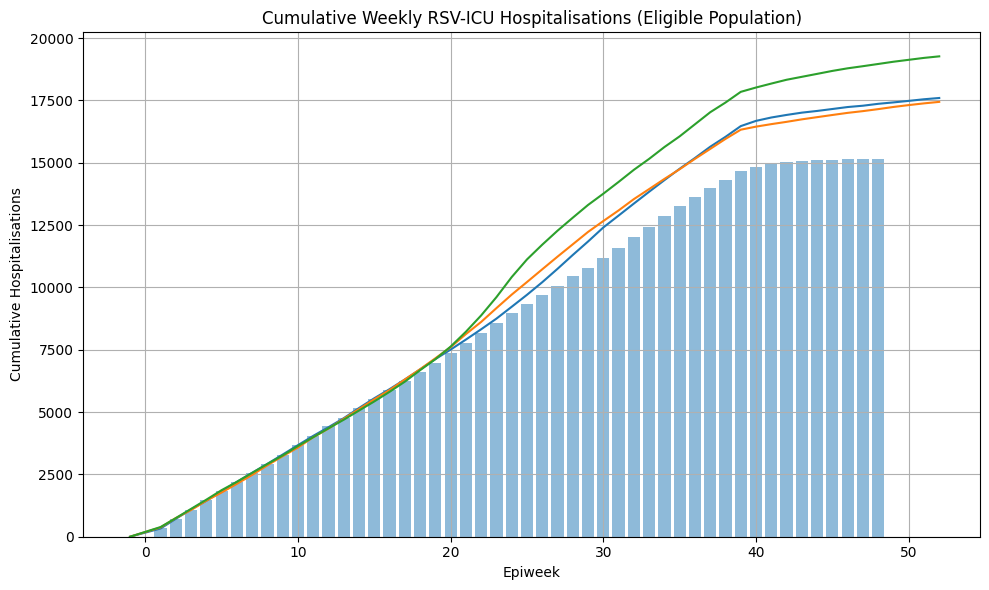

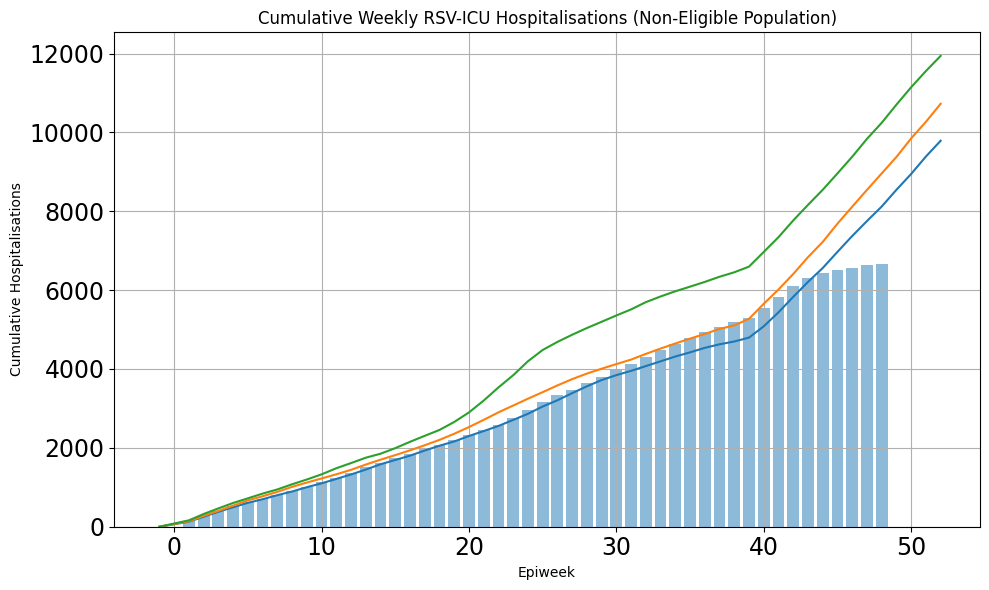

In [130]:
df_nirse_upc = df_historic.assign(is_elegible = lambda x: x.year == x.elegibilidad,
                              hospitalizado = lambda x: x['critico']==1)

df_elig = df_nirse_upc[df_nirse_upc['is_elegible'] == True]
df_no_elig = df_nirse_upc[df_nirse_upc['is_elegible'] == False]



df_elig_agg = (df_elig.groupby(['year', 'epiweekupc'])['hospitalizado']
                      .sum()
                      .reset_index())

# Ahora, calcular el acumulado por año
df_elig_agg['hospitalizado_acumulado'] = df_elig_agg.groupby('year')['hospitalizado'].cumsum()

df_no_elig_agg = (df_no_elig.groupby(['year', 'epiweekupc'])['hospitalizado']
                          .sum()
                          .reset_index())

df_no_elig_agg['hospitalizado_acumulado'] = df_no_elig_agg.groupby('year')['hospitalizado'].cumsum()

years_line = [2019, 2022, 2023]
year_hist = 2024

df_elig_line = df_elig_agg[df_elig_agg['year'].isin(years_line)]
df_elig_hist = df_elig_agg[df_elig_agg['year'] == year_hist]

fig, ax = plt.subplots(figsize=(10,6))

# Graficar las líneas
for y in years_line:
    data_y = df_elig_line[df_elig_line['year'] == y]
    
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))
    

data_2024 = df_elig_hist
ax.bar(data_2024['epiweekupc'], data_2024['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek' )
ax.set_ylabel('Cumulative Hospitalisations')
ax.set_title('Cumulative Weekly RSV-ICU Hospitalisations (Eligible Population)')
#ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major')
ax.grid(True)
plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(10,6))

# Líneas para 2019, 2022, 2023
df_no_elig_line = df_no_elig_agg[df_no_elig_agg['year'].isin(years_line)]
df_no_elig_hist = df_no_elig_agg[df_no_elig_agg['year'] == year_hist]

for y in years_line:
    data_y = df_no_elig_line[df_no_elig_line['year'] == y]
    
    
    ax.plot(data_y['epiweekupc'], data_y['hospitalizado_acumulado'], label=str(y))
    
# Histograma para 2024
data_2024_no_elig = df_no_elig_hist
ax.bar(data_2024_no_elig['epiweekupc'], data_2024_no_elig['hospitalizado_acumulado'], 
       alpha=0.5, label='2024')

ax.set_xlabel('Epiweek')
ax.set_ylabel('Cumulative Hospitalisations')
ax.set_title('Cumulative Weekly RSV-ICU Hospitalisations (Non-Eligible Population)')
#ax.legend(fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.grid(True)
plt.tight_layout()
plt.show()